# 3. Lựa chọn đặc trưng

**Input:** `exps/feature4/x_train.csv, y_train.csv`  
**Output:** `exps/feature4/selected_features.json` — từ điển {tên_cách_chọn: [danh sách cột]}

BEGIN

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [3]:
MEMBER   = "TV4"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "feature_selection4"
FEATURE_SET = "feature4"
seed_everything()

## VIỆC CỦA TV4 — lựa chọn đặc trưng
1. Thêm cách chọn: `SelectKBest(f_regression)`, `RFE`, ngưỡng tương quan, Lasso với nhiều alpha.
2. So sánh số cột giữ lại vs. CV RMSE (vẽ đồ thị K – RMSE).
3. (Nâng cao) Làm selection **bên trong** từng fold để có điểm không lạc quan.

In [4]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import GradientBoostingRegressor
x_train, y_train, x_test, test_id = load_feature_set(FEATURE_SET)

[load] feature4: x_train (1456, 293), x_test (1459, 293)


## 3.1. Lasso (L1) — giữ các cột có hệ số khác 0

Lasso giữ 215/293 cột


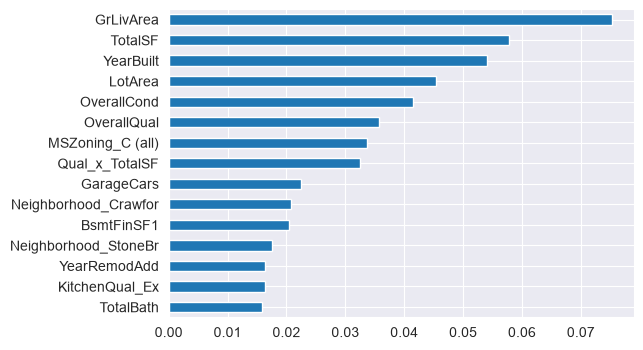

In [5]:
lasso = make_pipeline(Lasso(alpha=0.0005, max_iter=50000)).fit(x_train, y_train)
coef = pd.Series(lasso.named_steps['model'].coef_, index=x_train.columns)
sel_lasso = coef[coef != 0].index.tolist()
print(f'Lasso giữ {len(sel_lasso)}/{x_train.shape[1]} cột')
coef.abs().sort_values(ascending=False).head(15)[::-1].plot.barh(figsize=(6, 4)); plt.show()

## 3.2. Feature importance của Gradient Boosting — top K

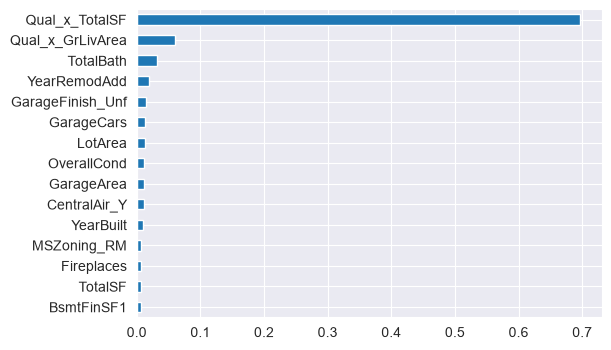

In [6]:
gbr = make_pipeline(GradientBoostingRegressor(n_estimators=300, random_state=SEED), scale=False).fit(x_train, y_train)
imp = pd.Series(gbr.named_steps['model'].feature_importances_, index=x_train.columns)
K = 50
sel_gbr = imp.sort_values(ascending=False).head(K).index.tolist()
imp.sort_values(ascending=False).head(15)[::-1].plot.barh(figsize=(6, 4)); plt.show()

## 3.3. So sánh nhanh bằng Ridge
⚠ Đặc trưng được chọn trên **toàn bộ** train rồi mới CV nên điểm hơi lạc quan; dùng để so sánh tương đối giữa các cách chọn.

In [7]:
selections = {'all': x_train.columns.tolist(), 'lasso': sel_lasso, f'gbr_top{K}': sel_gbr}
for name, cols in selections.items():
    scores, _ = evaluate(Ridge(alpha=10), x_train[cols], y_train)
    log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, 'Ridge', scores, selection=name)

[log] Ridge        | feature4/all | CV RMSE = 0.12080 ± 0.00555
[log] Ridge        | feature4/lasso | CV RMSE = 0.11661 ± 0.00492
[log] Ridge        | feature4/gbr_top50 | CV RMSE = 0.11141 ± 0.00587


[log] Ridge        | feature4/kbest25 | CV RMSE = 0.14164 ± 0.01188
[log] Ridge        | feature4/kbest50 | CV RMSE = 0.12934 ± 0.01031
[log] Ridge        | feature4/kbest100 | CV RMSE = 0.12543 ± 0.00569
[log] Ridge        | feature4/kbest150 | CV RMSE = 0.11759 ± 0.00379
[log] Ridge        | feature4/kbest200 | CV RMSE = 0.11875 ± 0.00436
[log] Ridge        | feature4/kbest250 | CV RMSE = 0.12166 ± 0.00198
[log] Ridge        | feature4/kbest293 | CV RMSE = 0.12080 ± 0.00555


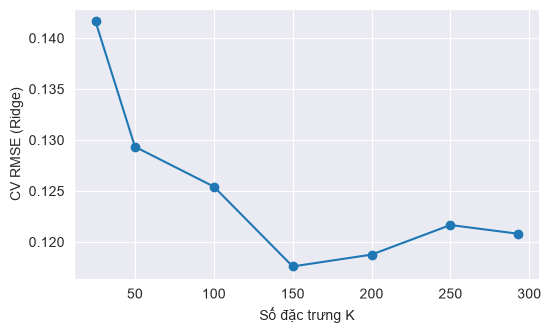

K tốt nhất: 150


In [8]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge

res = []
for k in [25, 50, 100, 150, 200, 250, x_train.shape[1]]:
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler()),
                     ('select', SelectKBest(f_regression, k=k)),     # chọn lại trong TỪNG fold
                     ('model', Ridge(alpha=10))])
    scores = -cross_val_score(pipe, x_train, y_train, cv=get_kfold(), scoring='neg_root_mean_squared_error')
    res.append((k, scores.mean()))
    log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, 'Ridge', scores, selection=f'kbest{k}', note='chọn trong fold')

plt.figure(figsize=(6, 3.5))
plt.plot(*zip(*res), marker='o'); plt.xlabel('Số đặc trưng K'); plt.ylabel('CV RMSE (Ridge)'); plt.show()

best_k = min(res, key=lambda r: r[1])[0]
sel = SelectKBest(f_regression, k=best_k).fit(x_train.fillna(x_train.median()), y_train)
selections[f'kbest{best_k}'] = x_train.columns[sel.get_support()].tolist()
print('K tốt nhất:', best_k)

In [9]:
with open(f'{feature_dir(FEATURE_SET)}/selected_features.json', 'w') as f:
    json.dump(selections, f, indent=1)
list(selections)

['all', 'lasso', 'gbr_top50', 'kbest150']

### Kết luận
- Chọn K = 150 bằng SelectKBest trong từng fold cho Ridge 0.1176, tốt hơn dùng toàn bộ 293 cột (0.1208). Kết quả gbr_top50 (0.1114) lạc quan hơn thực tế vì cột được chọn trên toàn bộ train trước khi CV.